In [47]:
# Spanish Real Estate Forecasting - Data Analysis
# This notebook is dedicated to performing data analysis on the cleaned real estate dataset. 
# I will explore the data, visualize trends, and extract insights that can inform our forecasting models. 
# It will include descriptive statistics, correlation analysis, and visualizations to understand the relationships between different features.

# Importing necessary libraries for data manipulation and file handling
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


In [48]:
# Loading the cleaned dataset from the pickle file for analysis 
BASE_DIR = Path.cwd().parent.parent
data_path = BASE_DIR / "data" / "cleaned_real_estate_data.pkl"
df = pd.read_pickle(data_path)

df.sample(5)

,ano,trim,geo,cod-ca,ca,cod-prv,prv,sector,variable,valor,tipo,metrica
140045,2018,2,provincia,1,andalucia,18,granada,commercial,nav-num,140.00,nav,num
3716,2019,4,comunidad,10,comunitat valenciana,98,comunitat valenciana,residential,viv-num,75151.00,viv,num
105521,2012,2,provincia,9,cataluna,17,girona,commercial,loc-num,448.00,loc,num
44071,2008,1,provincia,1,andalucia,23,jaen,residential,gar-imp,12072.00,gar,imp
128063,2014,3,provincia,10,comunitat valenciana,46,valencia / valencia,commercial,loc-pm2,960.62,loc,pm2


In [49]:
# Checking the number of records for each year and trimester to understand the distribution of data over time
df.groupby(["ano", "trim"]).size()

ano   trim
2007  1       1080
      2       1080
      3       1080
      4       1080
2008  1       1080
              ... 
2024  4       1080
2025  1       1080
      2       1080
      3       1080
      4       1080
Length: 76, dtype: int64

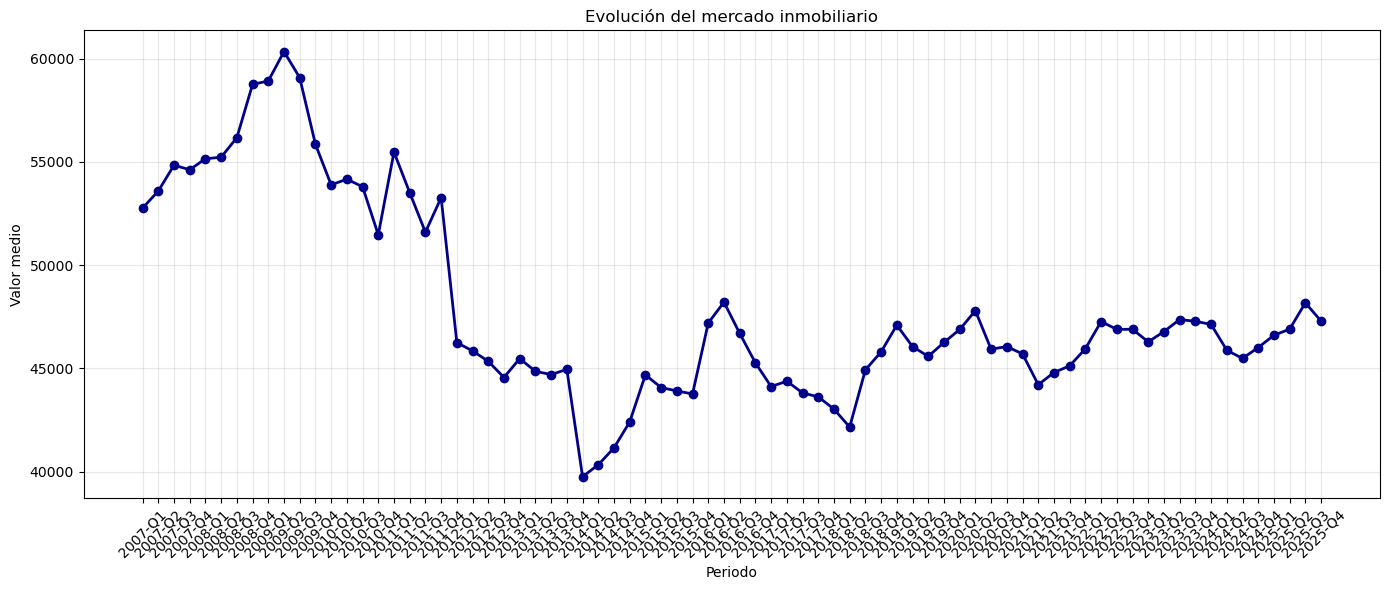

In [50]:
# Visualizing the average property value over time to identify trends and patterns in the real estate market
ts = df.groupby(["ano", "trim"])["valor"].mean().reset_index()
ts["periodo"] = ts["ano"].astype(str) + "-Q" + ts["trim"].astype(str)

plt.figure(figsize=(14,6))

plt.plot(ts["periodo"], ts["valor"], linewidth=2, marker="o", color="darkblue")

plt.xticks(rotation=45)
plt.title("Evolución del mercado inmobiliario")
plt.xlabel("Periodo")
plt.ylabel("Valor medio")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

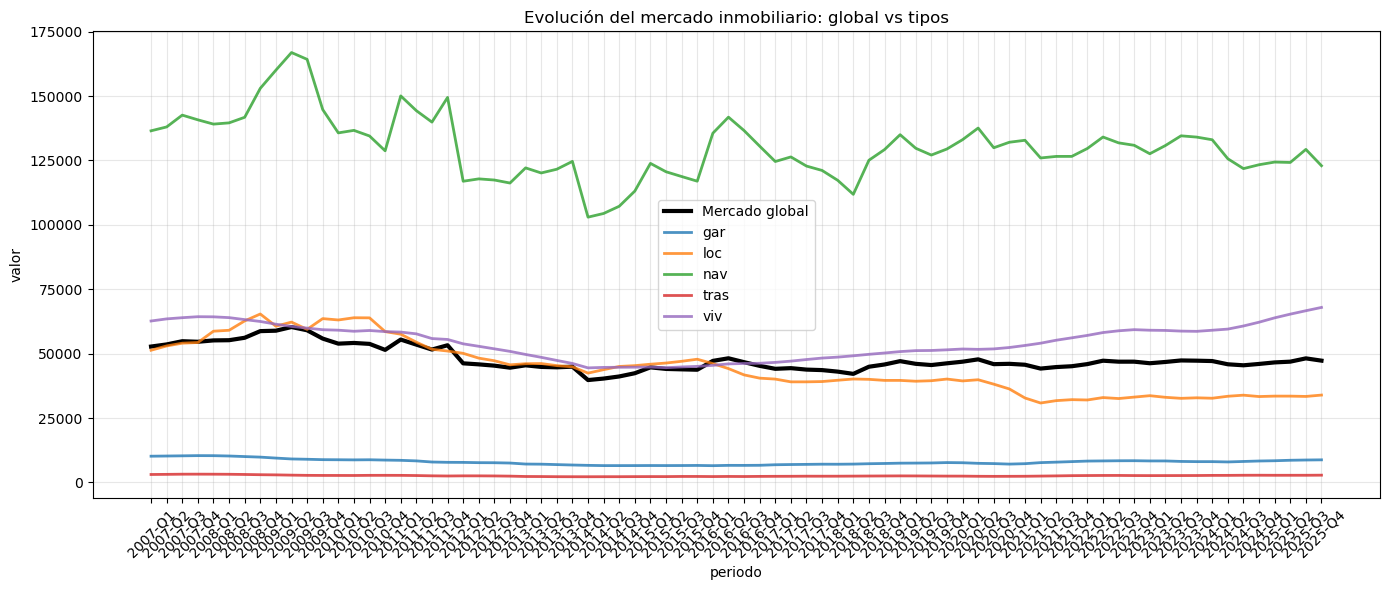

In [56]:
# Exploring the distribution of property values by type to identify differences in market segments.
# This can help us understand which types of properties are more valuable and how they contribute to the overall market.

ts_global = df.groupby(["ano", "trim"])["valor"].mean().reset_index()
ts_global["periodo"] = ts_global["ano"].astype(str) + "-Q" + ts_global["trim"].astype(str)
ts_tipo = df.groupby(["ano", "trim", "tipo"])["valor"].mean().reset_index()
ts_tipo["periodo"] = ts_tipo["ano"].astype(str) + "-Q" + ts_tipo["trim"].astype(str)

plt.figure(figsize=(14,6))

# Global
sns.lineplot(
    data=ts_global,
    x="periodo",
    y="valor",
    label="Mercado global",
    linewidth=3,
    color="black"
)

# Por tipo
sns.lineplot(
    data=ts_tipo,
    x="periodo",
    y="valor",
    hue="tipo",
    linewidth=2,
    alpha=0.8
)

plt.xticks(rotation=45)
plt.title("Evolución del mercado inmobiliario: global vs tipos")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [62]:
# Exploring the average property value by province to identify regional differences in the real estate market
df.groupby("prv")["valor"].mean().sort_values(ascending=False).round(2)

prv
barcelona              108875.88
espana                 108510.68
madrid                  96059.62
comunidad de madrid     96059.62
cataluna                92691.42
                         ...    
huelva                  25889.25
badajoz                 25058.79
extremadura             24508.28
jaen                    23865.44
caceres                 21959.44
Name: valor, Length: 67, dtype: float64

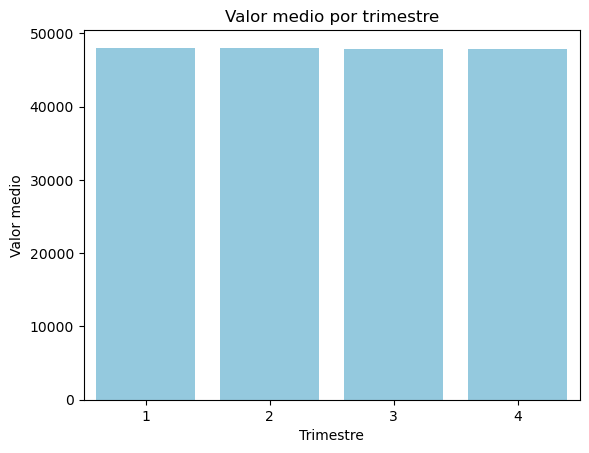

In [45]:
# Visualizing the average property value by trimester to identify seasonal trends in the real estate market
df.groupby("trim")["valor"].mean().reset_index()
sns.barplot(x="trim", y="valor", data=df.groupby("trim")["valor"].mean().reset_index(), color="skyblue")
plt.title("Valor medio por trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Valor medio")
plt.show()


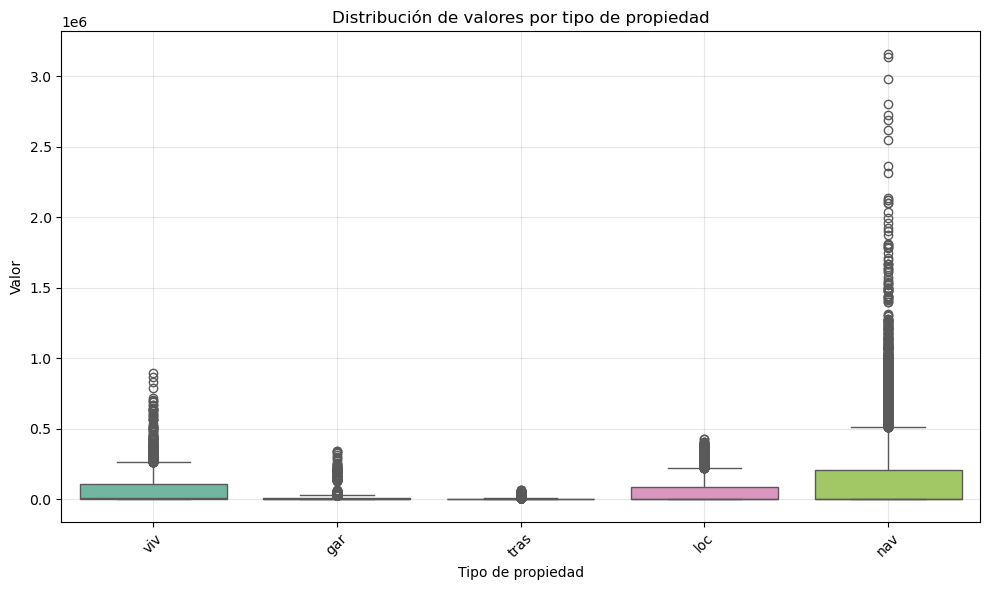

In [ ]:
# Exploring the distribution of property values by type to identify differences in market segments.
# Despite seeing the overall trend, it's important to understand how different types of properties are distributed in terms of value, 
# as this can inform our forecasting models and market analysis.Therefore, I have decided to maintain the outliers to get a complete picture 
# of the distribution, including any extreme values that may be present in the dataset (e.g., luxury properties or undervalued properties).
plt.figure(figsize=(10,6))
sns.boxplot(x="tipo", y="valor", data=df, palette="Set2", showfliers=True, hue="tipo")
plt.title("Distribución de valores por tipo de propiedad")
plt.xlabel("Tipo de propiedad")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

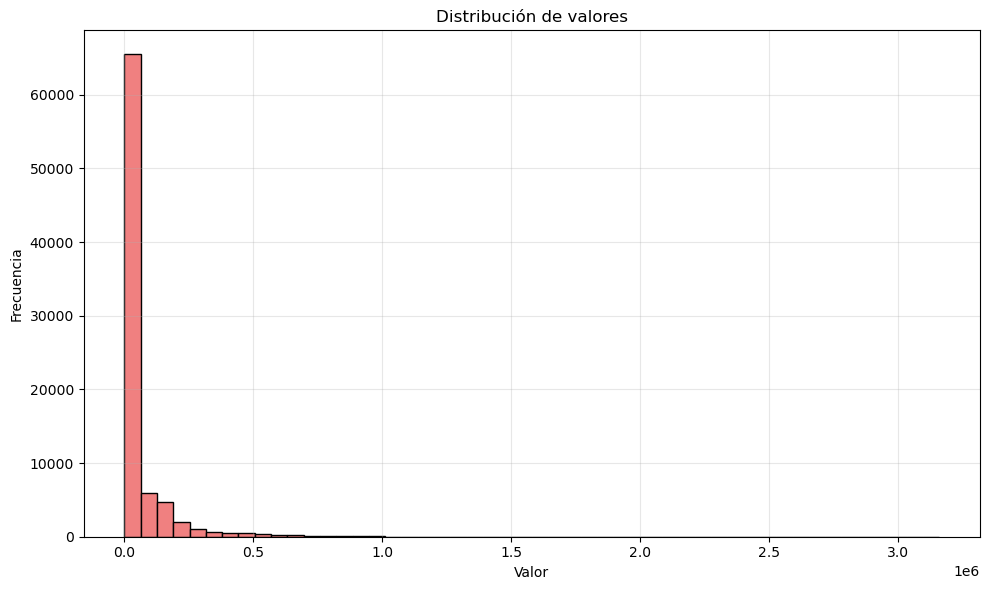

In [60]:
# Visualizing the distribution of property values to understand the range and identify any skewness or outliers in the data.
fig, ax = plt.subplots(figsize=(10,6))
df["valor"].hist(bins=50, color="lightcoral", edgecolor="black")
plt.title("Distribución de valores")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.tight_layout()

In [53]:
df.isna().sum()
df.duplicated().sum()

0

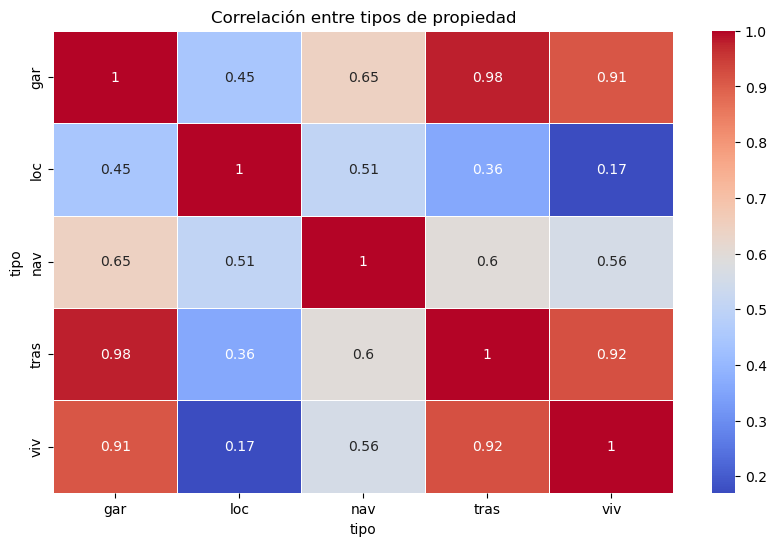

In [61]:
# Heatmap of correlations between different property types to understand how they relate to each other in terms of average value over time.
pivot = df.pivot_table(values="valor", index="ano", columns="tipo")
plt.figure(figsize=(10,6))
sns.heatmap(pivot.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlación entre tipos de propiedad")
plt.show()

In [ ]:
# Exploring the average property value by province, type, and metric to identify regional differences across different property types and metrics.
df.groupby(["prv", "tipo", "metrica"])["valor"].mean()

prv       tipo  metrica
a coruna  gar   imp         13488.394737
                num          3789.473684
                pm2          1050.624737
          loc   imp        128215.394737
                num           856.473684
                               ...      
zaragoza  tras  num          1137.868421
                pm2          1017.987632
          viv   imp        142675.855263
                num          9138.789474
                pm2          1640.782632
Name: valor, Length: 1005, dtype: float64